This is colorectal cancer dataset, work on this for classification problem. 'Survival_5_years'  is target variable. Choose any algorithms and compare the results.

In [1]:
import pandas as pd

In [2]:
df = pd.read_csv('colorectal_cancer_dataset.csv')
df.head()

,Patient_ID,Country,Age,Gender,Cancer_Stage,Tumor_Size_mm,Family_History,Smoking_History,Alcohol_Consumption,Obesity_BMI,...,Survival_5_years,Mortality,Healthcare_Costs,Incidence_Rate_per_100K,Mortality_Rate_per_100K,Urban_or_Rural,Economic_Classification,Healthcare_Access,Insurance_Status,Survival_Prediction
0,1,UK,77,M,Localized,69,No,No,Yes,Overweight,...,Yes,No,54413,50,5,Urban,Developed,Moderate,Insured,Yes
1,2,UK,59,M,Localized,33,No,No,No,Overweight,...,Yes,No,76553,37,25,Urban,Developing,High,Uninsured,Yes
2,3,Japan,66,M,Regional,17,No,Yes,No,Normal,...,Yes,No,62805,54,27,Urban,Developed,Moderate,Uninsured,No
3,4,USA,83,M,Regional,14,No,No,No,Obese,...,Yes,No,89393,45,11,Urban,Developed,Moderate,Insured,Yes
4,5,France,66,M,Localized,34,No,Yes,No,Normal,...,Yes,No,66425,15,27,Urban,Developing,High,Insured,Yes


In [3]:
df.columns

Index(['Patient_ID', 'Country', 'Age', 'Gender', 'Cancer_Stage',
       'Tumor_Size_mm', 'Family_History', 'Smoking_History',
       'Alcohol_Consumption', 'Obesity_BMI', 'Diet_Risk', 'Physical_Activity',
       'Diabetes', 'Inflammatory_Bowel_Disease', 'Genetic_Mutation',
       'Screening_History', 'Early_Detection', 'Treatment_Type',
       'Survival_5_years', 'Mortality', 'Healthcare_Costs',
       'Incidence_Rate_per_100K', 'Mortality_Rate_per_100K', 'Urban_or_Rural',
       'Economic_Classification', 'Healthcare_Access', 'Insurance_Status',
       'Survival_Prediction'],
      dtype='object')

In [4]:
df.describe()

,Patient_ID,Age,Tumor_Size_mm,Healthcare_Costs,Incidence_Rate_per_100K,Mortality_Rate_per_100K
count,167497.000000,167497.00000,167497.000000,167497.000000,167497.000000,167497.000000
mean,83749.000000,69.20078,42.005708,72452.168099,34.531562,17.023875
std,48352.363357,11.87247,21.672206,27402.779597,14.447970,7.208766
min,1.000000,30.00000,5.000000,25000.000000,10.000000,5.000000
25%,41875.000000,59.00000,23.000000,48760.000000,22.000000,11.000000
50%,83749.000000,69.00000,42.000000,72344.000000,35.000000,17.000000
75%,125623.000000,79.00000,61.000000,96227.000000,47.000000,23.000000
max,167497.000000,89.00000,79.000000,119999.000000,59.000000,29.000000


In [5]:
df.isnull().sum()

Patient_ID                    0
Country                       0
Age                           0
Gender                        0
Cancer_Stage                  0
Tumor_Size_mm                 0
Family_History                0
Smoking_History               0
Alcohol_Consumption           0
Obesity_BMI                   0
Diet_Risk                     0
Physical_Activity             0
Diabetes                      0
Inflammatory_Bowel_Disease    0
Genetic_Mutation              0
Screening_History             0
Early_Detection               0
Treatment_Type                0
Survival_5_years              0
Mortality                     0
Healthcare_Costs              0
Incidence_Rate_per_100K       0
Mortality_Rate_per_100K       0
Urban_or_Rural                0
Economic_Classification       0
Healthcare_Access             0
Insurance_Status              0
Survival_Prediction           0
dtype: int64

Our target variable is 'Survival_5_years'

In [6]:
df['Survival_5_years'].describe()

count     167497
unique         2
top          Yes
freq      100387
Name: Survival_5_years, dtype: object

In [7]:
df.dtypes

Patient_ID                     int64
Country                       object
Age                            int64
Gender                        object
Cancer_Stage                  object
Tumor_Size_mm                  int64
Family_History                object
Smoking_History               object
Alcohol_Consumption           object
Obesity_BMI                   object
Diet_Risk                     object
Physical_Activity             object
Diabetes                      object
Inflammatory_Bowel_Disease    object
Genetic_Mutation              object
Screening_History             object
Early_Detection               object
Treatment_Type                object
Survival_5_years              object
Mortality                     object
Healthcare_Costs               int64
Incidence_Rate_per_100K        int64
Mortality_Rate_per_100K        int64
Urban_or_Rural                object
Economic_Classification       object
Healthcare_Access             object
Insurance_Status              object
S

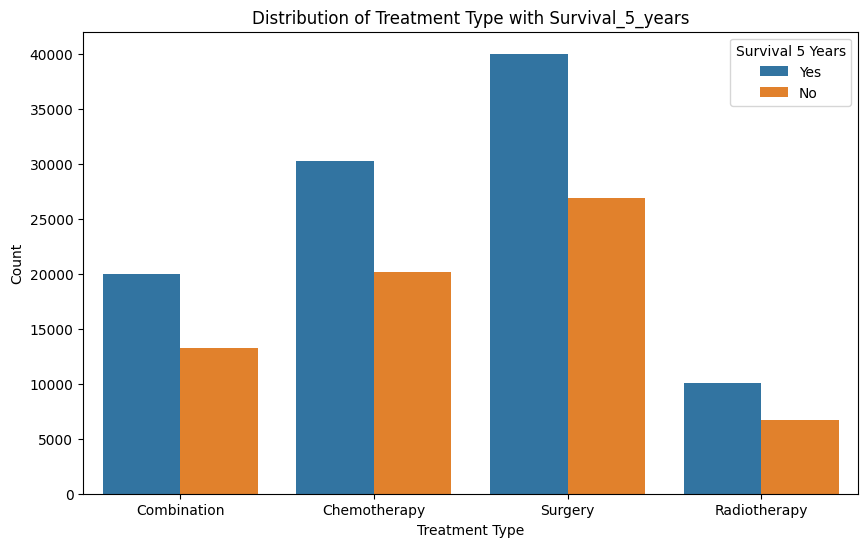

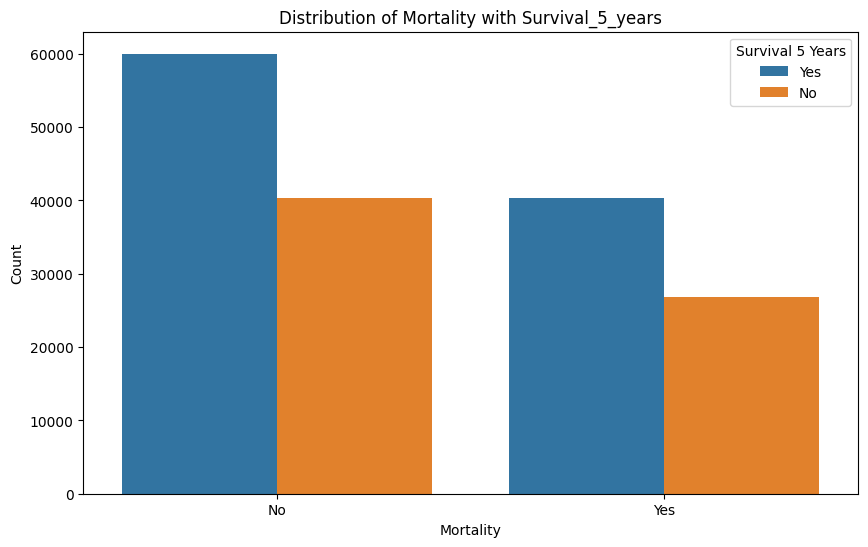

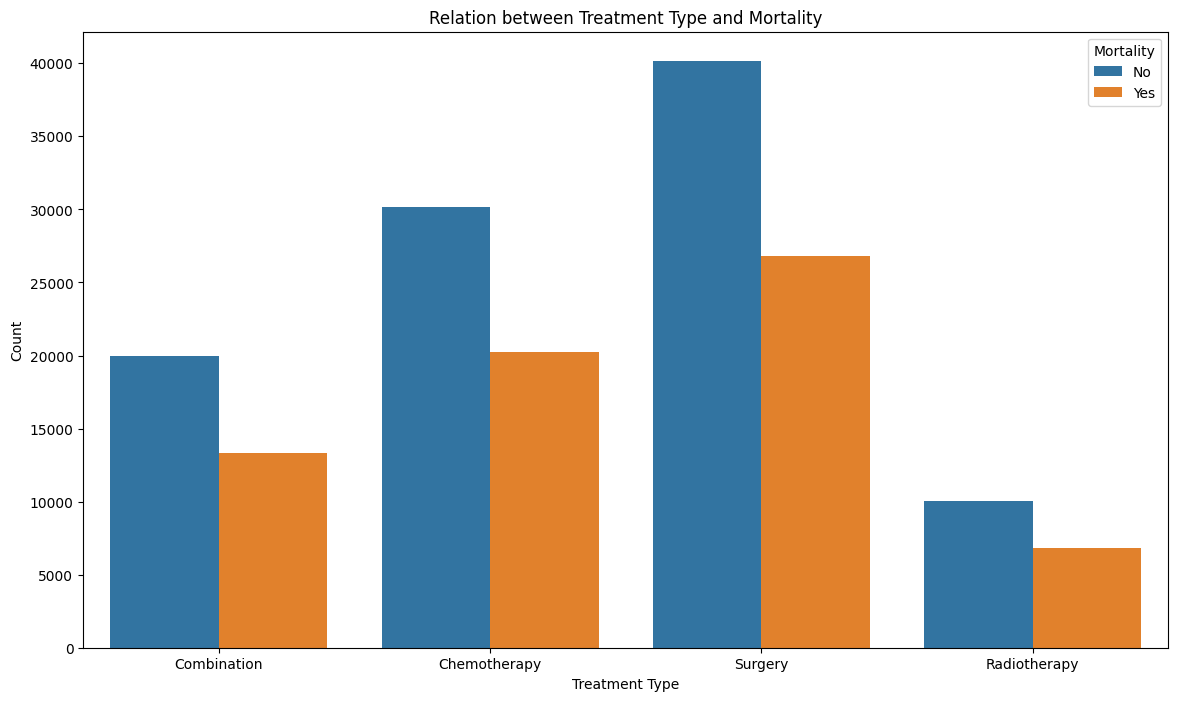

Survival_5_years     No    Yes
Treatment_Type                
Chemotherapy      20180  30263
Combination       13275  20001
Radiotherapy       6738  10106
Surgery           26917  40017
Survival_5_years     No    Yes
Mortality                     
No                40347  60007
Yes               26763  40380


In [8]:
import seaborn as sns

import matplotlib.pyplot as plt

# Distribution of 'Treatment_Type'
plt.figure(figsize=(10, 6))
sns.countplot(data=df, x='Treatment_Type', hue='Survival_5_years')
plt.title('Distribution of Treatment Type with Survival_5_years')
plt.xlabel('Treatment Type')
plt.ylabel('Count')
plt.legend(title='Survival 5 Years')
plt.show()

# Distribution of 'Mortality'
plt.figure(figsize=(10, 6))
sns.countplot(data=df, x='Mortality', hue='Survival_5_years')
plt.title('Distribution of Mortality with Survival_5_years')
plt.xlabel('Mortality')
plt.ylabel('Count')
plt.legend(title='Survival 5 Years')
plt.show()

# Relation between 'Treatment_Type' and 'Mortality' with 'Survival_5_years'
plt.figure(figsize=(14, 8))
sns.countplot(data=df, x='Treatment_Type', hue='Mortality')
plt.title('Relation between Treatment Type and Mortality')
plt.xlabel('Treatment Type')
plt.ylabel('Count')
plt.legend(title='Mortality')
plt.show()

# Crosstab for 'Treatment_Type' and 'Survival_5_years'
treatment_survival_crosstab = pd.crosstab(df['Treatment_Type'], df['Survival_5_years'])
print(treatment_survival_crosstab)

# Crosstab for 'Mortality' and 'Survival_5_years'
mortality_survival_crosstab = pd.crosstab(df['Mortality'], df['Survival_5_years'])
print(mortality_survival_crosstab)

In [9]:
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import classification_report, confusion_matrix

# Prepare the data
X = df.drop(columns=['Survival_5_years'])
y = df['Survival_5_years']

In [10]:
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

# Identify categorical and numerical columns
categorical_cols = X.select_dtypes(include=['object', 'bool']).columns
numerical_cols = X.select_dtypes(include=['int64', 'float64']).columns

# Define the column transformer
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numerical_cols),
        ('cat', OneHotEncoder(drop='first'), categorical_cols)
    ])

# Apply the transformations to the data
X_preprocessed = preprocessor.fit_transform(X)

# Convert the result back to a DataFrame
X_preprocessed_df = pd.DataFrame(X_preprocessed, columns=preprocessor.get_feature_names_out())

# Display the preprocessed data
X_preprocessed_df.head()

,num__Patient_ID,num__Age,num__Tumor_Size_mm,num__Healthcare_Costs,num__Incidence_Rate_per_100K,num__Mortality_Rate_per_100K,cat__Country_Brazil,cat__Country_Canada,cat__Country_China,cat__Country_France,...,cat__Treatment_Type_Combination,cat__Treatment_Type_Radiotherapy,cat__Treatment_Type_Surgery,cat__Mortality_Yes,cat__Urban_or_Rural_Urban,cat__Economic_Classification_Developing,cat__Healthcare_Access_Low,cat__Healthcare_Access_Moderate,cat__Insurance_Status_Uninsured,cat__Survival_Prediction_Yes
0,-1.732040,0.656918,1.245576,-0.658299,1.070634,-1.667957,0.0,0.0,0.0,0.0,...,1.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,1.0
1,-1.732020,-0.859199,-0.415543,0.149651,0.170851,1.106451,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,1.0,1.0
2,-1.731999,-0.269598,-1.153818,-0.352052,1.347490,1.383892,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,1.0,0.0
3,-1.731978,1.162291,-1.292245,0.618218,0.724563,-0.835634,0.0,0.0,0.0,0.0,...,0.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0,1.0
4,-1.731958,-0.269598,-0.369401,-0.219948,-1.351859,1.383892,0.0,0.0,0.0,1.0,...,0.0,0.0,1.0,0.0,1.0,1.0,0.0,0.0,0.0,1.0


In [11]:
# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X_preprocessed_df, y, test_size=0.3, random_state=42)

# Initialize the Decision Tree Classifier
clf = DecisionTreeClassifier(random_state=42)

# Train the classifier
clf.fit(X_train, y_train)

# Make predictions
y_pred = clf.predict(X_test)

# Evaluate the classifier
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

Confusion Matrix:
[[ 8232 11824]
 [12487 17707]]

Classification Report:
              precision    recall  f1-score   support

          No       0.40      0.41      0.40     20056
         Yes       0.60      0.59      0.59     30194

    accuracy                           0.52     50250
   macro avg       0.50      0.50      0.50     50250
weighted avg       0.52      0.52      0.52     50250



In [12]:
from sklearn.ensemble import RandomForestClassifier

# Initialize the Random Forest Classifier
rf_clf = RandomForestClassifier(random_state=42)

# Train the classifier
rf_clf.fit(X_train, y_train)

# Make predictions
y_pred_rf = rf_clf.predict(X_test)

# Evaluate the classifier
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_rf))
print("\nClassification Report:")
print(classification_report(y_test, y_pred_rf))

Confusion Matrix:
[[ 1214 18842]
 [ 1848 28346]]

Classification Report:
              precision    recall  f1-score   support

          No       0.40      0.06      0.11     20056
         Yes       0.60      0.94      0.73     30194

    accuracy                           0.59     50250
   macro avg       0.50      0.50      0.42     50250
weighted avg       0.52      0.59      0.48     50250



In [13]:
from sklearn.model_selection import GridSearchCV

# Define the parameter grid for the Decision Tree Classifier
param_grid = {
    'criterion': ['gini', 'entropy'],
    'max_depth': [None, 10, 20, 30, 40, 50],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}

# Initialize the GridSearchCV object
grid_search = GridSearchCV(estimator=clf, param_grid=param_grid, cv=5, n_jobs=-1, verbose=2)

# Perform the grid search on the training data
grid_search.fit(X_train, y_train)

# Get the best parameters and the best estimator
best_params = grid_search.best_params_
best_estimator = grid_search.best_estimator_

print("Best Parameters:", best_params)
print("Best Estimator:", best_estimator)

# Make predictions using the best estimator
y_pred_best = best_estimator.predict(X_test)

# Evaluate the best estimator
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_best))
print("\nClassification Report:")
print(classification_report(y_test, y_pred_best))

Fitting 5 folds for each of 108 candidates, totalling 540 fits
Best Parameters: {'criterion': 'entropy', 'max_depth': 10, 'min_samples_leaf': 1, 'min_samples_split': 5}
Best Estimator: DecisionTreeClassifier(criterion='entropy', max_depth=10, min_samples_split=5,
                       random_state=42)
Confusion Matrix:
[[  204 19852]
 [  345 29849]]

Classification Report:
              precision    recall  f1-score   support

          No       0.37      0.01      0.02     20056
         Yes       0.60      0.99      0.75     30194

    accuracy                           0.60     50250
   macro avg       0.49      0.50      0.38     50250
weighted avg       0.51      0.60      0.46     50250



In [18]:
# Define the parameter grid for the Random Forest Classifier
param_grid_rf = {
    'n_estimators': [100],
    'criterion': ['gini', 'entropy'],
    'max_depth': [None, 10, 20],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}

# Initialize the GridSearchCV object for Random Forest
grid_search_rf = GridSearchCV(estimator=rf_clf, param_grid=param_grid_rf, cv=5, n_jobs=-1, verbose=2)

# Perform the grid search on the training data
grid_search_rf.fit(X_train, y_train)

# Get the best parameters and the best estimator
best_params_rf = grid_search_rf.best_params_
best_estimator_rf = grid_search_rf.best_estimator_

print("Best Parameters for Random Forest:", best_params_rf)
print("Best Estimator for Random Forest:", best_estimator_rf)

# Make predictions using the best estimator
y_pred_best_rf = best_estimator_rf.predict(X_test)

# Evaluate the best estimator
print("Confusion Matrix for Random Forest:")
print(confusion_matrix(y_test, y_pred_best_rf))
print("\nClassification Report for Random Forest:")
print(classification_report(y_test, y_pred_best_rf))

Fitting 5 folds for each of 54 candidates, totalling 270 fits


PicklingError: Could not pickle the task to send it to the workers.

In [16]:
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

# Apply PCA to reduce dimensionality
pca = PCA()
X_pca = pca.fit_transform(X_preprocessed)

# Determine the optimal number of components
explained_variance = pca.explained_variance_ratio_.cumsum()
optimal_components = next(i for i, v in enumerate(explained_variance) if v >= 0.95) + 1
print(f"Optimal number of PCA components: {optimal_components}")

# Apply PCA with the optimal number of components
pca = PCA(n_components=optimal_components)
X_pca_optimal = pca.fit_transform(X_preprocessed)

# Use KMeans to find the optimal number of clusters
silhouette_scores = []
K = range(2, 11)  # Testing for 2 to 10 clusters

for k in K:
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(X_pca_optimal)
    labels = kmeans.labels_
    silhouette_scores.append(silhouette_score(X_pca_optimal, labels))

optimal_clusters = K[silhouette_scores.index(max(silhouette_scores))]
print(f"Optimal number of clusters: {optimal_clusters}")

# List the optimal number of clusters
print(f"Silhouette scores for different clusters: {silhouette_scores}")

Optimal number of PCA components: 36


KeyboardInterrupt: 